<h1>Model potpuno povezane neuronske mreže</h1>
<h2>Uvođenje potrebnih paketa</h2>

In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [45]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.utils import to_categorical

In [46]:
from sklearn import preprocessing
from sklearn import model_selection
from sklearn import metrics

In [47]:
import keras

In [48]:
import os
import random

In [49]:
import joblib

Kako bi se model mogao reprodukovati koristi se sledeća ćelija

In [50]:
seed_value = 7

os.environ["PYTHONHASHSEED"] = str(seed_value)
os.environ["TF_DETERMINISTIC_OPS"] = "1"  

random.seed(seed_value)
np.random.seed(seed_value)
tf.random.set_seed(seed_value)

<h2>Učitavanje pretprocesiranih podataka</h2>

In [51]:
data = pd.read_csv('preprocessed_data.csv', index_col=0)

In [52]:
data.head()

,Education Level,Finance,Science,Business,Computer Science,Arts,Psychology,Commerce,Engineering,Counseling,...,Marketing,Tally ERP,AWS Certified,Mental Health Basics,Digital Marketing,CFA Level 1,Creative Writing,Google Data Analytics,CGPA/Percentage,Recommended Career
0,2,1,0,0,0,0,0,0,0,1,...,0,1,0,0,0,0,0,0,67,Business Analyst
1,1,0,1,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,67,Software Engineer
2,3,0,0,1,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,90,Financial Analyst
3,2,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,75,Clerk
4,0,0,0,1,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,83,Sales Assistant


In [53]:
target = 'Recommended Career'

<h2>Izdvajanje atributa</h2>

In [54]:
x = data.drop(target, axis=1)
number_of_features = x.shape[1]
number_of_features

27

In [55]:
x.head()

,Education Level,Finance,Science,Business,Computer Science,Arts,Psychology,Commerce,Engineering,Counseling,...,Python,Marketing,Tally ERP,AWS Certified,Mental Health Basics,Digital Marketing,CFA Level 1,Creative Writing,Google Data Analytics,CGPA/Percentage
0,2,1,0,0,0,0,0,0,0,1,...,0,0,1,0,0,0,0,0,0,67
1,1,0,1,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,67
2,3,0,0,1,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,90
3,2,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,75
4,0,0,0,1,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,83


<h2>Izdvajanje i label enkodovanje ciljne promenljive</h2>

In [56]:
y = data[target]
y.head()

0     Business Analyst
1    Software Engineer
2    Financial Analyst
3                Clerk
4      Sales Assistant
Name: Recommended Career, dtype: object

In [57]:
number_of_classes = len(y.unique())

In [58]:
target_names = data[target].unique()

y = data[target]

label_encoder = preprocessing.LabelEncoder()
y_encoded = label_encoder.fit_transform( data[target] )

y_encoded

array([ 0, 11,  3, ...,  3, 11,  1], shape=(5000,))

In [59]:
y

0        Business Analyst
1       Software Engineer
2       Financial Analyst
3                   Clerk
4         Sales Assistant
              ...        
4995                Clerk
4996     School Counselor
4997    Financial Analyst
4998    Software Engineer
4999                Clerk
Name: Recommended Career, Length: 5000, dtype: object

<h2>Podela podataka na skupove za treniranje i testiranje i standardizacija</h2>
U opštem slučaju se vrši podela podataka na skup nad kojim će model trenirati(trening skup), skup nad kojim će se vršiti evaluacija modela u cilju izbora optimalnih parametara(validacioni skup) i skup koji će se koristiti za evaluaciju modela i davanje konačne ocene tog modela(test skup), ali kako sami modeli neuronskih mreža omogućavaju podelu trening skupa na skup za treniranje i validaciju nju nije potrebno ručno izvršavati. Podela se vrši pomoću funkcije train_test_split pri čemu uzimamo trećinu podataka za skup za testiranje. Takođe vodimo računa o stratifikaciji da bi udeo klasa ciljne promenljive u skupu za treniranje i testiranje bio procentualno jednak. Parametar random_state postavljamo na vrednost 7 kako bi se model mogao reprodukovati.

In [60]:
x_train, x_test, y_train, y_test = model_selection.train_test_split(x, y_encoded, test_size=0.33, stratify=y, random_state=7)

In [61]:
scaler = preprocessing.StandardScaler()

In [62]:
scaler.fit(x_train)

,copy,True
,with_mean,True
,with_std,True


In [63]:
x_train = scaler.transform(x_train)
x_test = scaler.transform(x_test)

<h2>Pretvaranje ciljne promenljive u oblik koji je pogodan za model neuronskih mreža</h2>

In [64]:
y_train = to_categorical(y_train, number_of_classes)
y_test = to_categorical(y_test, number_of_classes)

<h2>Pravljenje i treniranje modela potpuno povezanih neuronskih mreža</h2>
Uključivanje dodatnih paketa potrebnih za model neuronskih mreža

In [65]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import InputLayer, Dense
from tensorflow.keras.optimizers import Adam

In [66]:
model = Sequential()

In [67]:
model.add(InputLayer(shape=(number_of_features,)))
model.add(Dense(units=15, activation='relu'))
model.add(Dense(units=8, activation='relu'))
model.add(Dense(units=number_of_classes, activation='softmax'))

In [68]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                      │ (None, 15)                  │             420 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 8)                   │             128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 12)                  │             108 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 656 (2.56 KB)

 Trainable params: 656 (2.56 KB)

 Non-trainable params: 0 (0.00 B)

In [69]:
learning_rate = 0.001
number_of_epochs = 50
batch_size = 32

Za funkciju gubitka smo izabrali kategoričku unakrsnu entropiju, a za optimizator Adam sa parametrom learning_rate=0.001

In [70]:
model.compile(loss = 'categorical_crossentropy', optimizer=Adam(learning_rate), metrics=['accuracy'])

In [71]:
history = model.fit(x_train, y_train, epochs=number_of_epochs, batch_size=batch_size,validation_split=0.2)

Epoch 1/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0836 - loss: 2.5456 - val_accuracy: 0.1030 - val_loss: 2.5075
Epoch 2/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.0888 - loss: 2.5068 - val_accuracy: 0.0970 - val_loss: 2.4983
Epoch 3/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.0925 - loss: 2.4918 - val_accuracy: 0.0940 - val_loss: 2.4949
Epoch 4/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.0955 - loss: 2.4842 - val_accuracy: 0.0970 - val_loss: 2.4936
Epoch 5/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.1004 - loss: 2.4792 - val_accuracy: 0.0896 - val_loss: 2.4931
Epoch 6/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.1022 - loss: 2.4752 - val_accuracy: 0.0851 - val_loss: 2.4929
Epoch 7/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.1022 - loss: 2.4716 - val_accuracy: 0.0881 - val_loss: 2.4931
Epoch 8/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.1078 - loss: 2.4679 - val_accuracy: 0.0925 - val_loss:

Prikazivanje procesa treniranja pomoću grafika

In [72]:
epochs = history.epoch
loss = history.history['loss']
validation_loss = history.history['val_loss']

acc = history.history['accuracy']
validation_acc = history.history['val_accuracy']

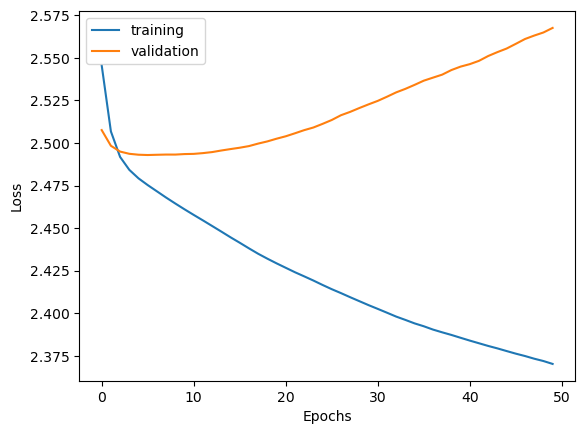

In [73]:
plt.plot(epochs, loss, label='training')
plt.plot(epochs, validation_loss, label='validation')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='best')
plt.show()

In [74]:
history.history['val_accuracy']

[0.10298507660627365,
 0.09701492637395859,
 0.09402985125780106,
 0.09701492637395859,
 0.08955223858356476,
 0.08507462590932846,
 0.08805970102548599,
 0.09253731369972229,
 0.08805970102548599,
 0.08805970102548599,
 0.08656716346740723,
 0.0835820883512497,
 0.08507462590932846,
 0.08208955079317093,
 0.0835820883512497,
 0.08656716346740723,
 0.09104477614164352,
 0.09402985125780106,
 0.08955223858356476,
 0.08656716346740723,
 0.08805970102548599,
 0.08805970102548599,
 0.08805970102548599,
 0.09402985125780106,
 0.09104477614164352,
 0.09104477614164352,
 0.08955223858356476,
 0.08955223858356476,
 0.09104477614164352,
 0.09253731369972229,
 0.09552238881587982,
 0.09253731369972229,
 0.09104477614164352,
 0.08805970102548599,
 0.08507462590932846,
 0.08507462590932846,
 0.08059701323509216,
 0.08208955079317093,
 0.08208955079317093,
 0.08507462590932846,
 0.0791044756770134,
 0.07611940056085587,
 0.07611940056085587,
 0.07611940056085587,
 0.07611940056085587,
 0.0761194005

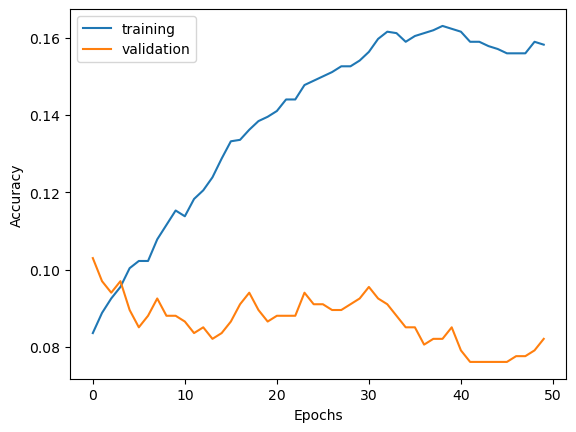

In [75]:
plt.plot(epochs, acc, label='training')
plt.plot(epochs, validation_acc, label='validation')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='best')
plt.show()

Vidimo da je model počeo da se preprilagođava već nakon treće epohe

In [76]:
train_score = model.evaluate(x_train, y_train)
train_score

105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 908us/step - accuracy: 0.1445 - loss: 2.4035


[2.403500556945801, 0.14447760581970215]

In [77]:
train_score = model.evaluate(x_test, y_test)
train_score

52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.0721 - loss: 2.5899 


[2.589884042739868, 0.07212121039628983]

Na osnovu rezultata vidimo da ni model potpuno povezanih neuronskih mreža nije uspeo da nauči zavisnost između atributa i ciljne promenljive pa na osnovu ovog i prethodnih rezultata zaključujemo da zavisnost između atributa i ciljne promenljive najverovatnije i ne postoji. Kako bismo se uverili u to sami smo pogledali skup podataka kako bismo proverili da li se i mi sami slažemo sa preporukama karijere na osnovu poznatih atributa. Na kraju ove sveske daćemo i par nama nelogičnih instanci (iako ih u skupu podataka ima mnogo više)

U nastavku dajemo i ostale metrike koje su prikazivane i za ostale modele

In [78]:
y_test_classes = np.argmax(y_test, axis=1)
y_test_classes

array([5, 1, 5, ..., 5, 1, 7], shape=(1650,))

In [79]:
y_test_predicted = model.predict(x_test)

52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


In [80]:
y_test_predicted

array([[0.08171301, 0.07769169, 0.0851782 , ..., 0.0584412 , 0.08366337,
        0.08310319],
       [0.06482475, 0.04718445, 0.05652727, ..., 0.06793532, 0.14768289,
        0.06428388],
       [0.06904514, 0.08533721, 0.08042874, ..., 0.06772646, 0.08779113,
        0.10042401],
       ...,
       [0.11104529, 0.03294802, 0.11560143, ..., 0.07846554, 0.10181233,
        0.05767572],
       [0.12084639, 0.10644682, 0.06117256, ..., 0.03509713, 0.06267213,
        0.03290423],
       [0.06240055, 0.09175986, 0.1223109 , ..., 0.09956046, 0.07439051,
        0.11331224]], shape=(1650, 12), dtype=float32)

In [81]:
y_test_predicted_classes = np.argmax(y_test_predicted,axis=1)
y_test_predicted_classes

array([ 8, 10,  5, ...,  5,  4,  2], shape=(1650,))

In [82]:
y_test

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(1650, 12))

In [83]:
cm = metrics.confusion_matrix(y_test_classes, y_test_predicted_classes)
cm

array([[ 2, 20, 14,  8,  5, 12,  0,  7, 16,  7, 23, 16],
       [ 5, 17, 13,  7, 11, 17, 10,  6,  9,  8, 18, 22],
       [ 6, 28, 11,  5,  4, 20,  6,  4, 11,  8, 16, 17],
       [ 9, 18,  9, 10, 10, 15,  2,  9, 13,  9, 20, 12],
       [ 3, 17, 14,  9,  4, 20,  4, 10, 12,  5, 20, 18],
       [ 7, 29, 10,  7,  9, 14,  4,  7, 11,  6, 16, 22],
       [ 4, 17, 12,  3,  5, 21,  7,  7, 13, 14, 21, 19],
       [ 5, 18, 14,  6,  5, 20, 10,  6, 10,  6, 13, 21],
       [ 4, 22, 14, 11,  7, 18,  6,  7, 10,  9, 15, 15],
       [ 9, 27, 14,  2,  4, 18,  8,  2, 11,  5, 16, 20],
       [ 4, 19, 10,  5,  5, 17, 10,  8, 16,  9, 13, 22],
       [ 8, 23,  9,  6,  2, 20,  5,  9, 14,  6, 16, 20]])

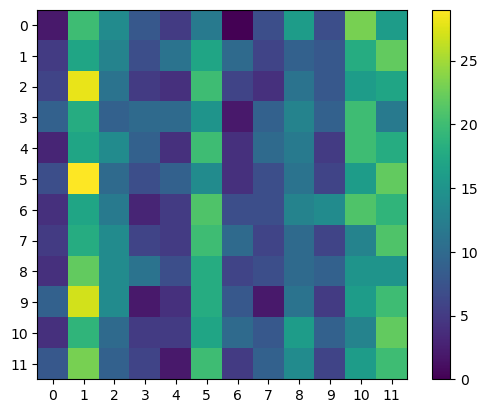

In [84]:
plt.imshow(cm)
plt.colorbar()
plt.xticks(np.arange(number_of_classes))
plt.yticks(np.arange(number_of_classes))
plt.show()

In [85]:
print(metrics.classification_report(y_test_classes, y_test_predicted_classes))

              precision    recall  f1-score   support

           0       0.03      0.02      0.02       130
           1       0.07      0.12      0.09       143
           2       0.08      0.08      0.08       136
           3       0.13      0.07      0.09       136
           4       0.06      0.03      0.04       136
           5       0.07      0.10      0.08       142
           6       0.10      0.05      0.07       143
           7       0.07      0.04      0.06       134
           8       0.07      0.07      0.07       138
           9       0.05      0.04      0.04       136
          10       0.06      0.09      0.08       138
          11       0.09      0.14      0.11       138

    accuracy                           0.07      1650
   macro avg       0.07      0.07      0.07      1650
weighted avg       0.07      0.07      0.07      1650



<h2>Čuvanje modela</h2>

In [86]:
joblib.dump(label_encoder,  'Models/Fully conected neural network/label_encoder.pkl')

['Models/Fully conected neural network/label_encoder.pkl']

In [87]:
joblib.dump(scaler,  'Models/Fully conected neural network/standard_scaler.pkl')

['Models/Fully conected neural network/standard_scaler.pkl']

In [88]:
model.save('Models/Fully conected neural network/model.hdf5')

<h2>Označene instance skupa podataka na osnovu njihove smislenosti</h2>
<img src="oznacene instance.png">